In [ ]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join('..')))
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd
import importlib
import src.utils as utils
importlib.reload(utils)

from src.utils import load_and_split_data
from src.utils import train_and_evaluate
from src.utils import BaselineCNN
from src.utils import run_Experiment_C





In [9]:
x_train, y_train, x_val, y_val, x_test, y_test = load_and_split_data()

In [10]:
mean = np.mean(x_train, axis=(0,1,2))
std = np.std(x_train, axis=(0,1,2))

x_train_standardized = (x_train - mean) / std
x_val_standardized = (x_val - mean) / std
x_test_standardized = (x_test - mean) / std

In [11]:
x_train_resized = tf.image.resize(x_train_standardized, (48, 48)).numpy()
x_val_resized = tf.image.resize(x_val_standardized, (48, 48)).numpy()
x_test_resized = tf.image.resize(x_test_standardized, (48, 48)).numpy()

In [ ]:
print(x_train_resized.shape)
print(x_val_resized.shape)
print(x_test_resized.shape)

(40000, 48, 48, 3)


## Model 1: From Scratch

In [28]:
def build_medium_cnn_48():
    model = models.Sequential([
        layers.Input(shape=(48,48,3)),

        layers.Conv2D(32, 3, activation='relu', padding='same'),
        layers.Conv2D(32, 3, activation='relu', padding='same'),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(64, 3, activation='relu', padding='same'),
        layers.Conv2D(64, 3, activation='relu', padding='same'),
        layers.MaxPooling2D(2,2),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    return model

In [29]:
model1 = build_medium_cnn_48()

model1.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [41]:
hist1, acc1, loss1, time1 = train_and_evaluate(
    model1,
    x_train_resized, y_train,
    x_val_resized, y_val,
    x_test_resized, y_test
)

Test Acc: 0.6876 | Test Loss: 2.6120 | Time:1074.9s


## Model 2 — Feature Extraction (Frozen VGG16)

In [31]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models

base_model2 = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(48, 48, 3)
)

In [32]:
for layer in base_model2.layers:
    layer.trainable = False

In [33]:
model2 = models.Sequential([
    base_model2,
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

In [34]:
model2.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [25]:
model2.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 1, 1, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,586 (56.64 MB)

 Trainable params: 133,898 (523.04 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [43]:
hist2, acc2, loss2, time2 = train_and_evaluate(
    model2,
    x_train_resized, y_train, 
    x_val_resized, y_val,
    x_test_resized, y_test
)

Test Acc: 0.6902 | Test Loss: 0.8954 | Time:5101.0s


## Model 3 — Fine-Tuning (Partial Unfreeze)

In [35]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models

base_model3 = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(48, 48, 3)
)

In [36]:
for layer in base_model3.layers:
    layer.trainable = False

In [37]:
for layer in base_model3.layers[-4:]:
    layer.trainable = True

In [38]:
model3 = models.Sequential([
    base_model3,
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

In [39]:
model3.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [18]:
model3.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 1, 1, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,586 (56.64 MB)

 Trainable params: 7,213,322 (27.52 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

In [19]:
hist3, acc3, loss3, time3 = train_and_evaluate(
    model3,
    x_train_resized, y_train,
    x_val_resized, y_val,
    x_test_resized, y_test
)

Test Acc: 0.8256 | Test Loss: 0.5490 | Time:8298.2s


## Model 4 — Fine-Tuning (Higher Learning Rate)

In [20]:
from tensorflow.keras.applications import VGG16

base_model4 = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(48, 48, 3)
)

In [21]:
for layer in base_model4.layers:
    layer.trainable = False

In [22]:
for layer in base_model4.layers[-4:]:
    layer.trainable = True

In [23]:
from tensorflow.keras import layers, models

model4 = models.Sequential([
    base_model4,
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

In [24]:
from tensorflow import keras

model4.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001), 
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [26]:
hist4, acc4, loss4, time4 = train_and_evaluate(
    model4,
    x_train_resized, y_train,
    x_val_resized, y_val,
    x_test_resized, y_test
)

Test Acc: 0.1000 | Test Loss: 2.3026 | Time:5483.0s


## results table

In [44]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["From Scratch", "Feature Extraction", "Fine-Tune lr=1e-5", "Fine-Tune lr=1e-3"],
    "Trainable Params": [
        model1.count_params(),
        sum([tf.keras.backend.count_params(w) for w in model2.trainable_weights]),
        sum([tf.keras.backend.count_params(w) for w in model3.trainable_weights]),
        sum([tf.keras.backend.count_params(w) for w in model4.trainable_weights])
    ],
    "Non-Trainable Params": [
        0,
        sum([tf.keras.backend.count_params(w) for w in model2.non_trainable_weights]),
        sum([tf.keras.backend.count_params(w) for w in model3.non_trainable_weights]),
        sum([tf.keras.backend.count_params(w) for w in model4.non_trainable_weights])
    ],
    "Test Accuracy": [acc1, acc2, acc3, acc4],
    "Time (s)": [time1, time2, time3, time4]
})

results

,Model,Trainable Params,Non-Trainable Params,Test Accuracy,Time (s)
0,From Scratch,2427690,0,0.6876,1074.941088
1,Feature Extraction,133898,14714688,0.6902,5100.951955
2,Fine-Tune lr=1e-5,7213322,7635264,0.8256,8298.195818
3,Fine-Tune lr=1e-3,7213322,7635264,0.1000,5483.037109


## Plot: val accuracy curves — all 4 models on one graph

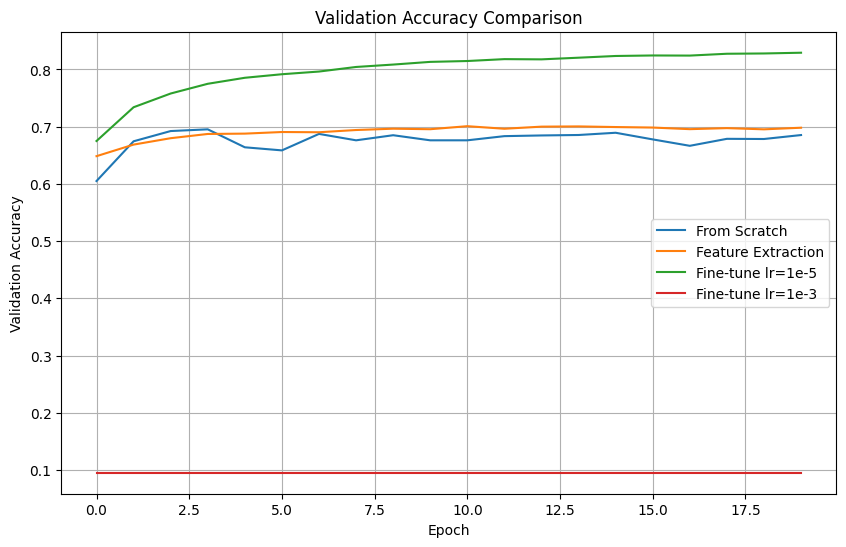

In [45]:
plt.figure(figsize=(10,6))

plt.plot(hist1.history['val_accuracy'], label='From Scratch')
plt.plot(hist2.history['val_accuracy'], label='Feature Extraction')
plt.plot(hist3.history['val_accuracy'], label='Fine-tune lr=1e-5')
plt.plot(hist4.history['val_accuracy'], label='Fine-tune lr=1e-3')

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy Comparison")
plt.legend()
plt.grid()
plt.show()

## Plot: val loss curves — all 4 models on one graph

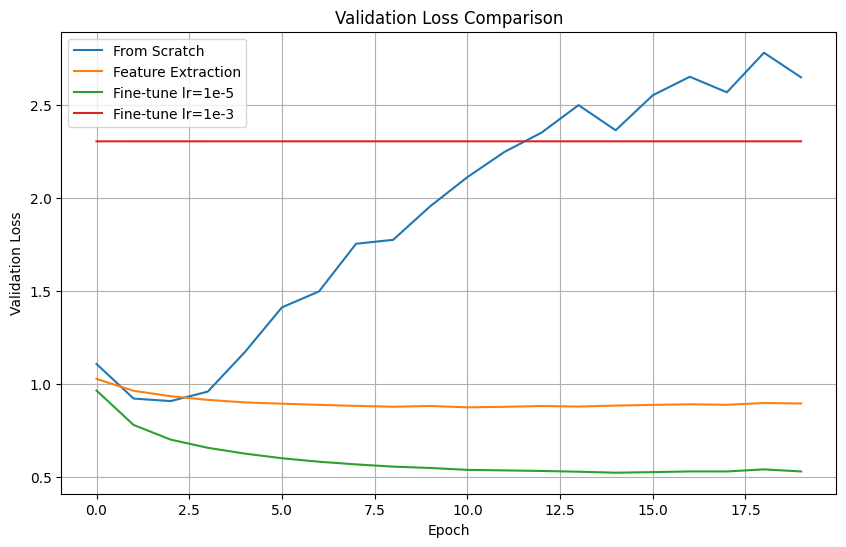

In [46]:
plt.figure(figsize=(10,6))

plt.plot(hist1.history['val_loss'], label='From Scratch')
plt.plot(hist2.history['val_loss'], label='Feature Extraction')
plt.plot(hist3.history['val_loss'], label='Fine-tune lr=1e-5')
plt.plot(hist4.history['val_loss'], label='Fine-tune lr=1e-3')

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss Comparison")
plt.legend()
plt.grid()
plt.show()

## Why does Model 4 (lr=0.001) perform differently from Model 3 (lr=1e-5)?
Model 4 performs worse because it uses a high learning rate (0.001), which causes large updates that destroy the pre-trained weights.
Model 3 uses a small learning rate (1e-5), allowing gradual updates and better performance.

## Does transfer learning outperform training from scratch on CIFAR-10? Why or why not?
Yes, transfer learning outperforms training from scratch.
The fine-tuned model achieved higher accuracy (0.82) compared to from scratch (0.69) because it uses pre-learned features from ImageNet.